In [6]:
# Euler's Method Solver
# Author: Owen Purnomo
# Date: 07/08/2026
# Euler's method approximates a curve by repeatedly taking small straight-line steps in the direction
# the slope function tells you to go, using each new point to recompute the direction for the next step.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [15]:
x, y = sp.symbols('x y')
y_func = sp.Function('y')

ode = sp.Eq(y_func(x).diff(x), -2 * x * y_func(x))
solution = sp.dsolve(ode, y_func(x), ics={y_func(0): 1})
print("Exact solution:", solution)


Exact solution: Eq(y(x), exp(-x**2))


In [16]:
exact_expr = solution.rhs
exact = sp.lambdify(x, exact_expr, 'numpy')

In [17]:
def euler_method(f, a, b, y0, n):
    h = (b - a) / n
    x_vals = np.zeros(n + 1)
    y_vals = np.zeros(n + 1)
    x_vals[0] = a
    y_vals[0] = y0
    for k in range(n):
        y_vals[k + 1] = y_vals[k] + h * f(x_vals[k], y_vals[k])
        x_vals[k + 1] = x_vals[k] + h
    return x_vals, y_vals


In [18]:
f2 = lambda x, y: -2 * x * y
x_vals, y_vals = euler_method(f2, a=0, b=2, y0=1, n=10)


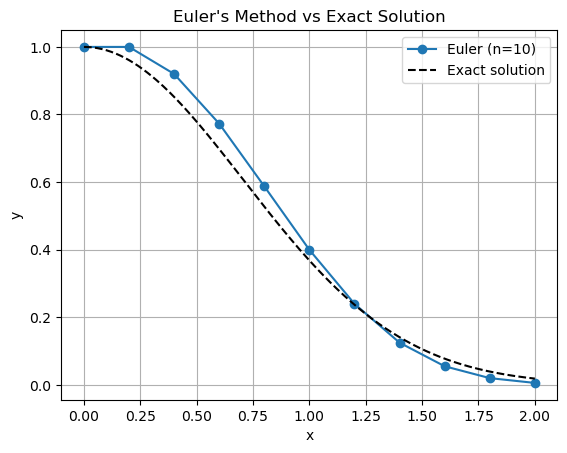

In [19]:
x_fine = np.linspace(0, 2, 200)
plt.plot(x_vals, y_vals, 'o-', label='Euler (n=10)')
plt.plot(x_fine, exact(x_fine), 'k--', label='Exact solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
error = np.abs(y_vals - exact(x_vals))
for xi, yi, ei in zip(x_vals, y_vals, error):
    print(f"x={xi:.2f}   Euler y={yi:.5f}   error={ei:.5f}")

x=0.00   Euler y=1.00000   error=0.00000
x=0.20   Euler y=1.00000   error=0.03921
x=0.40   Euler y=0.92000   error=0.06786
x=0.60   Euler y=0.77280   error=0.07512
x=0.80   Euler y=0.58733   error=0.06004
x=1.00   Euler y=0.39938   error=0.03150
x=1.20   Euler y=0.23963   error=0.00270
x=1.40   Euler y=0.12461   error=0.01625
x=1.60   Euler y=0.05483   error=0.02248
x=1.80   Euler y=0.01974   error=0.01943
x=2.00   Euler y=0.00553   error=0.01279


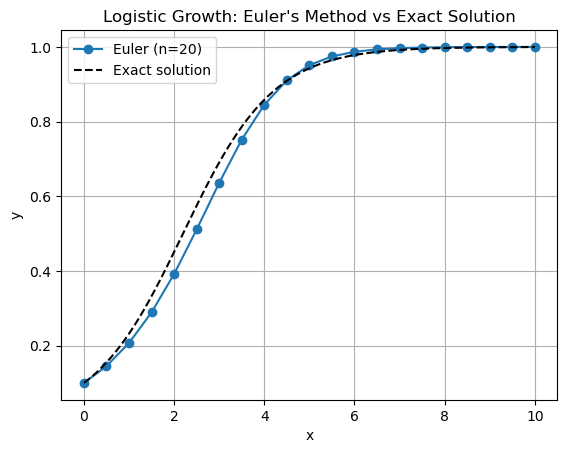

In [22]:
f3 = lambda x, y: y * (1 - y)

y0 = 0.1
exact_logistic = lambda x: (y0 * np.exp(x)) / (1 - y0 + y0 * np.exp(x))

x_vals, y_vals = euler_method(f3, a=0, b=10, y0=y0, n=20)

x_fine = np.linspace(0, 10, 300)
plt.plot(x_vals, y_vals, 'o-', label='Euler (n=20)')
plt.plot(x_fine, exact_logistic(x_fine), 'k--', label='Exact solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Logistic Growth: Euler's Method vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()

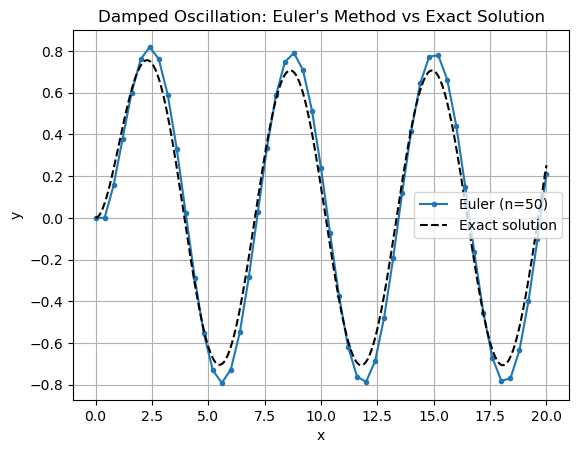

In [23]:
f4 = lambda x, y: -y + np.sin(x)

exact_oscillation = lambda x: 0.5 * (np.sin(x) - np.cos(x)) + 0.5 * np.exp(-x)

x_vals, y_vals = euler_method(f4, a=0, b=20, y0=0, n=50)

x_fine = np.linspace(0, 20, 500)
plt.plot(x_vals, y_vals, 'o-', markersize=3, label='Euler (n=50)')
plt.plot(x_fine, exact_oscillation(x_fine), 'k--', label='Exact solution')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Damped Oscillation: Euler's Method vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()